# DistilGPT2 Word-by-Word Representation Analysis

This notebook samples 500 rows from the Kaggle **sentiment analysis for mental health** dataset and feeds each sampled text into Hugging Face `distilgpt2` word by word, using growing prefixes.

`distilgpt2` is a causal language model, not a sentiment classifier. To make "sentiment representation" measurable, this notebook trains lightweight linear probes on frozen `distilgpt2` hidden states from the same 500-row sample:

- a binary probe for `Normal` vs `non-Normal`
- a multiclass probe for the dataset's `status` labels

The probes are analysis tools only. They do not fine-tune `distilgpt2`, and they are not clinical or diagnostic models.

## 1. Imports and M2 Pro configuration

The defaults are tuned for a MacBook with an Apple M2 Pro chip: use PyTorch MPS when available, run the model in float16 first, and automatically fall back to MPS float32 or CPU float32 if needed.

In [1]:
from pathlib import Path
import json
import os
import re
import warnings

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("datasets/Combined Data.csv")
OUTPUT_DIR = Path("outputs/distilgpt2_word_by_word")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "distilgpt2"
SAMPLE_ROWS = 5000
RANDOM_STATE = 42

# To keep every sampled text fully processed word by word, sample from rows up to this length.
# Set to None to allow arbitrarily long texts, but one 1000+ word post can dominate runtime.
MAX_SAMPLE_WORDS = 100

# GPT-2 has a 1024-token context window. 256 keeps M2 Pro runtime predictable.
# Prefixes longer than this are right-truncated by the tokenizer.
MAX_MODEL_TOKENS = 256

# Leave as None to choose hardware-aware defaults below.
FULL_TEXT_BATCH_SIZE = None
PREFIX_BATCH_SIZE = None

# Reuse saved artifacts on reruns unless settings changed.
FORCE_RECOMPUTE_FULL_TEXT = False
FORCE_RECOMPUTE_PREFIXES = False

USE_FLOAT16_ON_MPS = True

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if FULL_TEXT_BATCH_SIZE is None:
    FULL_TEXT_BATCH_SIZE = 96 if DEVICE.type in {"cuda", "mps"} else 16
if PREFIX_BATCH_SIZE is None:
    PREFIX_BATCH_SIZE = 64 if DEVICE.type in {"cuda", "mps"} else 12

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

mps_backend = getattr(torch.backends, "mps", None)
if mps_backend is not None:
    print(f"MPS built: {mps_backend.is_built()}; MPS available: {mps_backend.is_available()}")
print(f"Device: {DEVICE}")
print(f"Full-text batch size: {FULL_TEXT_BATCH_SIZE}")
print(f"Prefix batch size: {PREFIX_BATCH_SIZE}")

MPS built: True; MPS available: False
Device: cpu
Full-text batch size: 16
Prefix batch size: 12


In [2]:
import platform
print(platform.mac_ver())

('13.3', ('', '', ''), 'arm64')


## 2. Load and sample the dataset

The notebook samples exactly 500 rows when enough eligible rows are available. By default, eligible rows have at most `MAX_SAMPLE_WORDS` whitespace words so every sampled row can be processed through its whole text word by word.

In [3]:
def load_clean_dataset(path):
    data = pd.read_csv(path)
    data = data[["statement", "status"]].copy()
    data["statement"] = data["statement"].astype("string")
    data["status"] = data["status"].astype("string")
    data = data.dropna(subset=["statement", "status"])
    data["statement"] = data["statement"].str.strip()
    data = data[data["statement"] != ""].reset_index(drop=True)
    data["original_row_id"] = np.arange(len(data))
    data["word_count"] = data["statement"].str.split().str.len()
    return data


def stratified_sample_exact(data, n, label_col="status", random_state=42):
    rng = np.random.default_rng(random_state)
    labels = sorted(data[label_col].unique())
    base = n // len(labels)
    remainder = n % len(labels)
    sampled_parts = []
    used_indices = set()

    for i, label in enumerate(labels):
        group = data[data[label_col] == label]
        take = min(len(group), base + (1 if i < remainder else 0))
        part = group.sample(n=take, random_state=random_state + i)
        sampled_parts.append(part)
        used_indices.update(part.index.tolist())

    sample = pd.concat(sampled_parts, axis=0)
    if len(sample) < n:
        remaining = data.drop(index=list(used_indices))
        fill = remaining.sample(n=n - len(sample), random_state=random_state)
        sample = pd.concat([sample, fill], axis=0)

    sample = sample.sample(frac=1, random_state=random_state).reset_index(drop=True)
    sample["sample_id"] = np.arange(len(sample))
    return sample


data_df = load_clean_dataset(DATA_PATH)
eligible_df = data_df.copy()
if MAX_SAMPLE_WORDS is not None:
    eligible_df = eligible_df[eligible_df["word_count"] <= MAX_SAMPLE_WORDS].copy()

if len(eligible_df) < SAMPLE_ROWS:
    raise ValueError(f"Only {len(eligible_df)} eligible rows are available; reduce SAMPLE_ROWS or increase MAX_SAMPLE_WORDS.")

sample_df = stratified_sample_exact(eligible_df, SAMPLE_ROWS, random_state=RANDOM_STATE)
sample_df.to_csv(OUTPUT_DIR / "sample_500_rows.csv", index=False)

print(f"Clean rows: {len(data_df):,}")
print(f"Eligible rows: {len(eligible_df):,}")
print(f"Sample rows: {len(sample_df):,}")
display(sample_df[["sample_id", "original_row_id", "status", "word_count", "statement"]].head())
display(sample_df["status"].value_counts().rename_axis("status").to_frame("count"))
display(sample_df["word_count"].describe().to_frame("sample_word_count"))

Clean rows: 52,681
Eligible rows: 33,690
Sample rows: 5,000


,sample_id,original_row_id,status,word_count,statement
0,0,41166,Depression,39,depression cause feeling of sadness and or a l...
1,1,35902,Normal,4,She is not tired.
2,2,43943,Normal,14,mileycyrus http twitpic com y 0 i want a sofie...
3,3,45405,Bipolar,19,How do you deal with your kids while on a mani...
4,4,566,Anxiety,15,On the sidelines of anxiety there may be a lon...


,count
status,
Normal,871
Depression,785
Suicidal,775
Anxiety,722
Stress,720
Bipolar,717
Personality disorder,410


,sample_word_count
count,5000.00000
mean,46.94940
std,29.67906
min,1.00000
25%,19.00000
50%,47.00000
75%,73.00000
max,100.00000


## 3. Load DistilGPT2

This uses `AutoModel`, not a generation head, because the analysis only needs hidden states. GPT-2 tokenization is byte-pair encoding, so a whitespace "word" may become multiple model tokens.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.config.pad_token_id = tokenizer.pad_token_id

MODEL_DTYPE = torch.float16 if DEVICE.type == "mps" and USE_FLOAT16_ON_MPS else torch.float32
model.to(device=DEVICE, dtype=MODEL_DTYPE)
model.eval()

layer_names = ["embeddings"] + [f"layer_{i}" for i in range(1, model.config.n_layer + 1)]

print(f"Model: {MODEL_NAME}")
print(f"Device: {DEVICE}")
print(f"Model dtype: {MODEL_DTYPE}")
print(f"Hidden-state outputs: {len(layer_names)} -> {layer_names}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Model: distilgpt2
Device: cpu
Model dtype: torch.float32
Hidden-state outputs: 7 -> ['embeddings', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6']


## 4. Encoding helpers with MPS fallback

In [5]:
WORD_RE = re.compile(r"\S+")


def split_words(text):
    return WORD_RE.findall(str(text))


def build_prefixes(text):
    words = split_words(text)
    prefixes = [" ".join(words[:i]) for i in range(1, len(words) + 1)]
    return words, prefixes


def move_model(device, dtype):
    global DEVICE, MODEL_DTYPE, model, FULL_TEXT_BATCH_SIZE, PREFIX_BATCH_SIZE
    DEVICE = torch.device(device)
    MODEL_DTYPE = dtype
    model.to(device=DEVICE, dtype=MODEL_DTYPE)
    model.eval()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    else:
        FULL_TEXT_BATCH_SIZE = min(FULL_TEXT_BATCH_SIZE, 16)
        PREFIX_BATCH_SIZE = min(PREFIX_BATCH_SIZE, 12)
    print(f"Runtime now using device={DEVICE}, dtype={MODEL_DTYPE}")


def encode_text_batch_once(texts):
    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_MODEL_TOKENS,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE, non_blocking=True) for key, value in encoded.items()}
    with torch.inference_mode():
        outputs = model(**encoded, output_hidden_states=True, use_cache=False, return_dict=True)

    last_token_idx = encoded["attention_mask"].sum(dim=1) - 1
    batch_idx = torch.arange(last_token_idx.shape[0], device=DEVICE)
    vectors = torch.stack(
        [state[batch_idx, last_token_idx, :] for state in outputs.hidden_states],
        dim=1,
    )
    return vectors.detach().cpu().float().numpy()


def encode_text_batch(texts):
    try:
        return encode_text_batch_once(texts)
    except RuntimeError as err:
        message = str(err)
        if DEVICE.type == "mps" and MODEL_DTYPE == torch.float16:
            print("MPS float16 failed; retrying on MPS float32. Original error:")
            print(message[:600])
            move_model("mps", torch.float32)
            return encode_text_batch_once(texts)
        if DEVICE.type == "mps":
            print("MPS failed; retrying on CPU float32. Original error:")
            print(message[:600])
            move_model("cpu", torch.float32)
            return encode_text_batch_once(texts)
        raise


def encode_texts_all_layers(texts, batch_size, desc):
    chunks = []
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch_texts = texts[start : start + batch_size]
        chunks.append(encode_text_batch(batch_texts))
    return np.concatenate(chunks, axis=0)


def cosine_distance(a, b, eps=1e-8):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + eps
    return 1.0 - float(np.dot(a, b) / denom)

## 5. Encode full sampled texts

These full-text hidden states are used to train frozen-representation probes. The model itself is not trained.

In [6]:
full_vectors_path = OUTPUT_DIR / "full_text_vectors_by_layer.npy"
full_metadata_path = OUTPUT_DIR / "full_text_metadata.json"

full_metadata = {
    "model_name": MODEL_NAME,
    "sample_rows": SAMPLE_ROWS,
    "max_sample_words": MAX_SAMPLE_WORDS,
    "max_model_tokens": MAX_MODEL_TOKENS,
    "sample_original_row_ids": sample_df["original_row_id"].astype(int).tolist(),
    "layer_names": layer_names,
}

def full_cache_valid():
    if FORCE_RECOMPUTE_FULL_TEXT:
        return False
    if not full_vectors_path.exists() or not full_metadata_path.exists():
        return False
    with full_metadata_path.open() as f:
        return json.load(f) == full_metadata

if full_cache_valid():
    print("Loading cached full-text vectors.")
    full_text_vectors = np.load(full_vectors_path)
else:
    full_text_vectors = encode_texts_all_layers(
        sample_df["statement"].tolist(),
        batch_size=FULL_TEXT_BATCH_SIZE,
        desc="Encoding full texts",
    )
    np.save(full_vectors_path, full_text_vectors)
    with full_metadata_path.open("w") as f:
        json.dump(full_metadata, f, indent=2)

print("full_text_vectors shape:", full_text_vectors.shape)

Encoding full texts:   0%|          | 0/313 [00:00<?, ?it/s]

full_text_vectors shape: (5000, 7, 768)


## 6. Train frozen hidden-state probes

For each DistilGPT2 layer, train two probes on full-text representations:

- `Normal` vs `non-Normal`
- multiclass `status`

These probes provide scalar trajectories for the prefix and layer plots.

In [7]:
status_encoder = LabelEncoder()
y_status = status_encoder.fit_transform(sample_df["status"])
y_normal = (sample_df["status"].to_numpy() == "Normal").astype(int)

train_idx, test_idx = train_test_split(
    np.arange(len(sample_df)),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_status,
)

normal_probes = []
status_probes = []
probe_records = []

for layer_idx, layer_name in enumerate(layer_names):
    X = full_text_vectors[:, layer_idx, :]

    normal_probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    )
    normal_probe.fit(X[train_idx], y_normal[train_idx])
    normal_pred = normal_probe.predict(X[test_idx])
    normal_probes.append(normal_probe)

    status_probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    )
    status_probe.fit(X[train_idx], y_status[train_idx])
    status_pred = status_probe.predict(X[test_idx])
    status_probes.append(status_probe)

    probe_records.append(
        {
            "layer": layer_name,
            "normal_accuracy": accuracy_score(y_normal[test_idx], normal_pred),
            "normal_macro_f1": f1_score(y_normal[test_idx], normal_pred, average="macro"),
            "status_accuracy": accuracy_score(y_status[test_idx], status_pred),
            "status_macro_f1": f1_score(y_status[test_idx], status_pred, average="macro"),
        }
    )

probe_df = pd.DataFrame(probe_records)
probe_df.to_csv(OUTPUT_DIR / "probe_scores_by_layer.csv", index=False)
display(probe_df)

,layer,normal_accuracy,normal_macro_f1,status_accuracy,status_macro_f1
0,embeddings,0.8048,0.697710,0.3680,0.350995
1,layer_1,0.8880,0.818356,0.5208,0.516723
2,layer_2,0.8728,0.797262,0.4976,0.493228
3,layer_3,0.8648,0.777494,0.4896,0.486102
4,layer_4,0.8776,0.798559,0.4984,0.493498
5,layer_5,0.8872,0.813743,0.5784,0.576824
6,layer_6,0.8760,0.798571,0.6000,0.598245


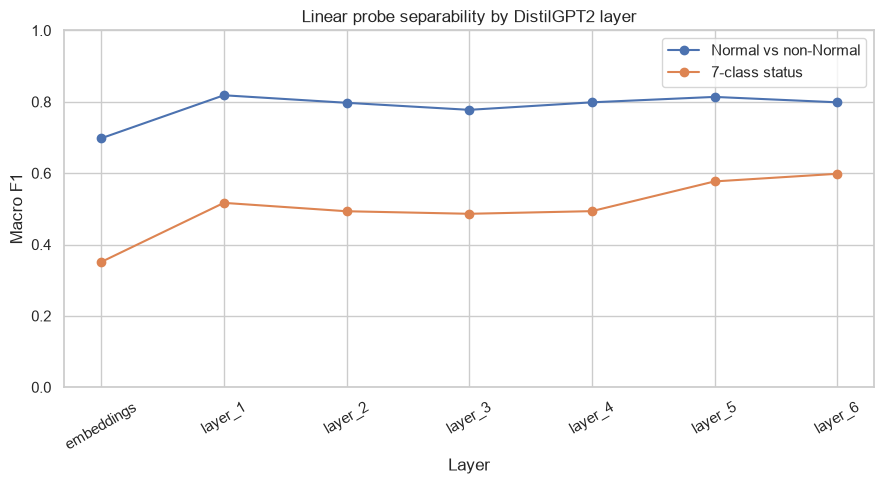

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(probe_df["layer"], probe_df["normal_macro_f1"], marker="o", label="Normal vs non-Normal")
ax.plot(probe_df["layer"], probe_df["status_macro_f1"], marker="o", label="7-class status")
ax.set_title("Linear probe separability by DistilGPT2 layer")
ax.set_xlabel("Layer")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "probe_scores_by_layer.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Word-by-word prefix analysis

For each of the 500 sampled rows, this feeds prefixes into `distilgpt2`:

- first word
- first two words
- first three words
- ...
- full sampled text

For each prefix, the notebook saves both last-layer trajectories and layer-by-layer trajectories.

In [9]:
prefix_last_path = OUTPUT_DIR / "prefix_last_layer_trajectory.csv"
prefix_layers_path = OUTPUT_DIR / "prefix_layer_trajectory_long.csv"
prefix_metadata_path = OUTPUT_DIR / "prefix_metadata.json"

prefix_metadata = {
    **full_metadata,
    "prefix_batch_size": PREFIX_BATCH_SIZE,
}

def prefix_cache_valid():
    if FORCE_RECOMPUTE_PREFIXES:
        return False
    if not prefix_last_path.exists() or not prefix_layers_path.exists() or not prefix_metadata_path.exists():
        return False
    with prefix_metadata_path.open() as f:
        return json.load(f) == prefix_metadata


def probe_layer_vectors(vectors_by_layer):
    normal_probs = []
    status_labels = []
    status_confidences = []
    for layer_idx in range(vectors_by_layer.shape[1]):
        X = vectors_by_layer[:, layer_idx, :]
        normal_probs.append(normal_probes[layer_idx].predict_proba(X)[:, 1])
        status_probs = status_probes[layer_idx].predict_proba(X)
        status_pred = status_probs.argmax(axis=1)
        status_labels.append(status_encoder.inverse_transform(status_pred))
        status_confidences.append(status_probs.max(axis=1))
    return np.stack(normal_probs, axis=1), np.stack(status_labels, axis=1), np.stack(status_confidences, axis=1)


def analyze_prefixes_for_row(row):
    words, prefixes = build_prefixes(row.statement)
    last_records = []
    layer_records = []
    previous_last_vector = None

    for start in range(0, len(prefixes), PREFIX_BATCH_SIZE):
        batch_prefixes = prefixes[start : start + PREFIX_BATCH_SIZE]
        batch_words = words[start : start + PREFIX_BATCH_SIZE]
        vectors = encode_text_batch(batch_prefixes)
        normal_probs, status_labels, status_confidences = probe_layer_vectors(vectors)

        for local_idx, added_word in enumerate(batch_words):
            prefix_idx = start + local_idx + 1
            layer_vectors = vectors[local_idx]
            last_vector = layer_vectors[-1]
            last_prefix_drift = np.nan if previous_last_vector is None else cosine_distance(last_vector, previous_last_vector)
            previous_last_vector = last_vector.copy()

            last_records.append(
                {
                    "sample_id": int(row.sample_id),
                    "original_row_id": int(row.original_row_id),
                    "status": str(row.status),
                    "prefix_word_count": int(prefix_idx),
                    "added_word": str(added_word),
                    "prefix_preview": batch_prefixes[local_idx][:180],
                    "last_layer_normal_probability": float(normal_probs[local_idx, -1]),
                    "last_layer_status_prediction": str(status_labels[local_idx, -1]),
                    "last_layer_status_confidence": float(status_confidences[local_idx, -1]),
                    "last_layer_drift_from_previous_prefix": float(last_prefix_drift) if np.isfinite(last_prefix_drift) else np.nan,
                }
            )

            for layer_idx, layer_name in enumerate(layer_names):
                delta_prev_layer = np.nan if layer_idx == 0 else cosine_distance(layer_vectors[layer_idx], layer_vectors[layer_idx - 1])
                cosine_to_embeddings = 1.0 - cosine_distance(layer_vectors[layer_idx], layer_vectors[0])
                layer_records.append(
                    {
                        "sample_id": int(row.sample_id),
                        "original_row_id": int(row.original_row_id),
                        "status": str(row.status),
                        "prefix_word_count": int(prefix_idx),
                        "layer": layer_name,
                        "normal_probability": float(normal_probs[local_idx, layer_idx]),
                        "status_prediction": str(status_labels[local_idx, layer_idx]),
                        "status_confidence": float(status_confidences[local_idx, layer_idx]),
                        "delta_from_previous_layer": float(delta_prev_layer) if np.isfinite(delta_prev_layer) else np.nan,
                        "cosine_to_embeddings": float(cosine_to_embeddings),
                    }
                )

    return last_records, layer_records


if prefix_cache_valid():
    print("Loading cached prefix trajectories.")
    prefix_last_df = pd.read_csv(prefix_last_path)
    prefix_layer_df = pd.read_csv(prefix_layers_path)
else:
    all_last_records = []
    all_layer_records = []
    for row in tqdm(sample_df.itertuples(index=False), total=len(sample_df), desc="Rows word by word"):
        last_records, layer_records = analyze_prefixes_for_row(row)
        all_last_records.extend(last_records)
        all_layer_records.extend(layer_records)

    prefix_last_df = pd.DataFrame.from_records(all_last_records)
    prefix_layer_df = pd.DataFrame.from_records(all_layer_records)
    prefix_last_df.to_csv(prefix_last_path, index=False)
    prefix_layer_df.to_csv(prefix_layers_path, index=False)
    with prefix_metadata_path.open("w") as f:
        json.dump(prefix_metadata, f, indent=2)

    if DEVICE.type == "mps":
        torch.mps.empty_cache()

print("Last-layer prefix rows:", prefix_last_df.shape)
print("Layer-by-prefix rows:", prefix_layer_df.shape)
display(prefix_last_df.head())

Rows word by word:   0%|          | 0/5000 [00:00<?, ?it/s]

Last-layer prefix rows: (234747, 10)
Layer-by-prefix rows: (1643229, 10)


,sample_id,original_row_id,status,prefix_word_count,added_word,prefix_preview,last_layer_normal_probability,last_layer_status_prediction,last_layer_status_confidence,last_layer_drift_from_previous_prefix
0,0,41166,Depression,1,depression,depression,8.856369e-02,Depression,0.930660,NaN
1,0,41166,Depression,2,cause,depression cause,7.983948e-07,Anxiety,0.899949,0.005517
2,0,41166,Depression,3,feeling,depression cause feeling,5.786470e-05,Anxiety,0.997282,0.007808
3,0,41166,Depression,4,of,depression cause feeling of,1.531723e-12,Anxiety,0.999997,0.007311
4,0,41166,Depression,5,sadness,depression cause feeling of sadness,2.493299e-03,Depression,0.999961,0.010576


## 8. Last-layer changes with growing prefixes

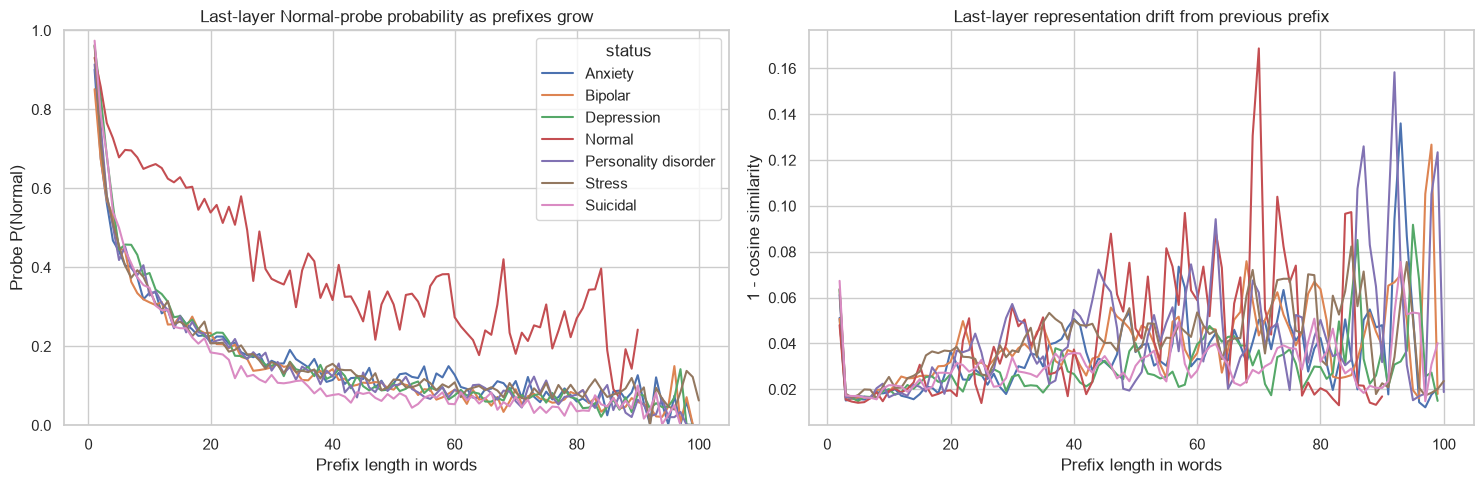

In [10]:
mean_prefix = (
    prefix_last_df.groupby(["status", "prefix_word_count"], as_index=False)
    .agg(
        normal_probability=("last_layer_normal_probability", "mean"),
        examples=("sample_id", "nunique"),
        drift=("last_layer_drift_from_previous_prefix", "mean"),
    )
)
# Drop late prefix positions with too few examples so the average is stable.
mean_prefix = mean_prefix[mean_prefix["examples"] >= 8]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(
    data=mean_prefix,
    x="prefix_word_count",
    y="normal_probability",
    hue="status",
    ax=axes[0],
)
axes[0].set_title("Last-layer Normal-probe probability as prefixes grow")
axes[0].set_xlabel("Prefix length in words")
axes[0].set_ylabel("Probe P(Normal)")
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=mean_prefix,
    x="prefix_word_count",
    y="drift",
    hue="status",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Last-layer representation drift from previous prefix")
axes[1].set_xlabel("Prefix length in words")
axes[1].set_ylabel("1 - cosine similarity")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "last_layer_prefix_trajectories_by_status.png", dpi=180, bbox_inches="tight")
plt.show()

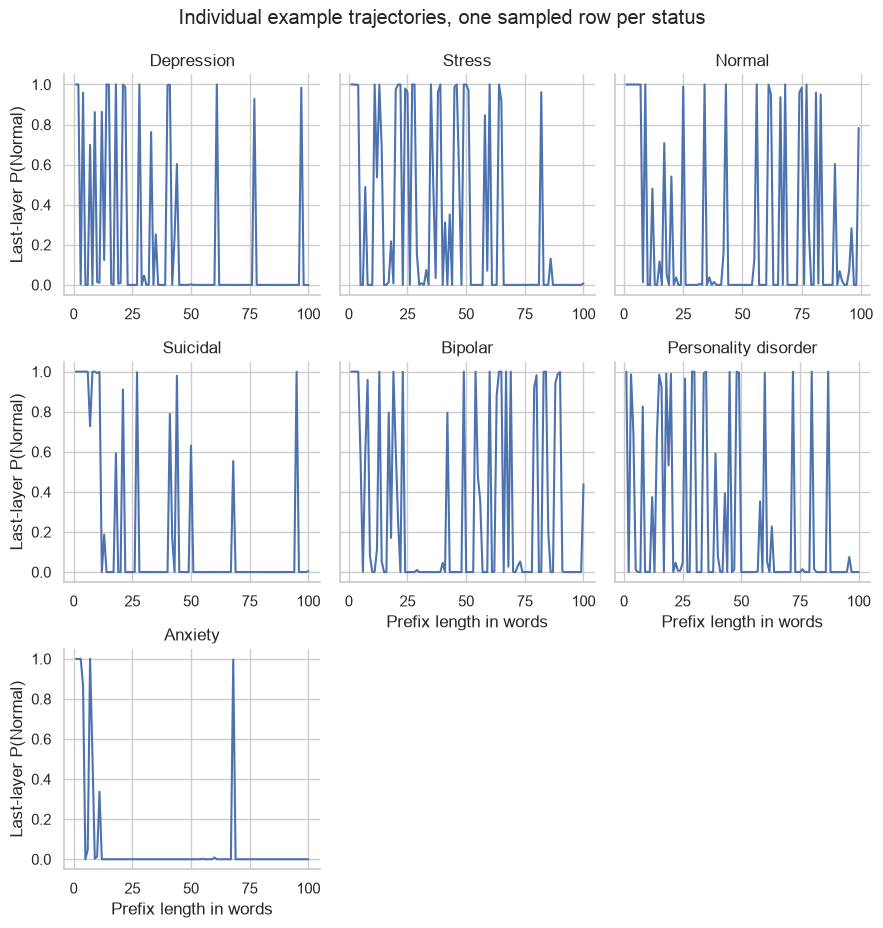

In [11]:
example_ids = []
for _, group in sample_df.groupby("status", sort=False):
    example_ids.append(int(group.sort_values("word_count", ascending=False)["sample_id"].iloc[0]))
example_df = prefix_last_df[prefix_last_df["sample_id"].isin(example_ids)].copy()

g = sns.relplot(
    data=example_df,
    x="prefix_word_count",
    y="last_layer_normal_probability",
    col="status",
    col_wrap=3,
    kind="line",
    height=3,
    facet_kws={"sharex": False},
)
g.set_axis_labels("Prefix length in words", "Last-layer P(Normal)")
g.set_titles("{col_name}")
g.fig.suptitle("Individual example trajectories, one sampled row per status", y=1.03)
g.fig.savefig(OUTPUT_DIR / "example_last_layer_prefix_trajectories.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Layer-to-layer changes across DistilGPT2

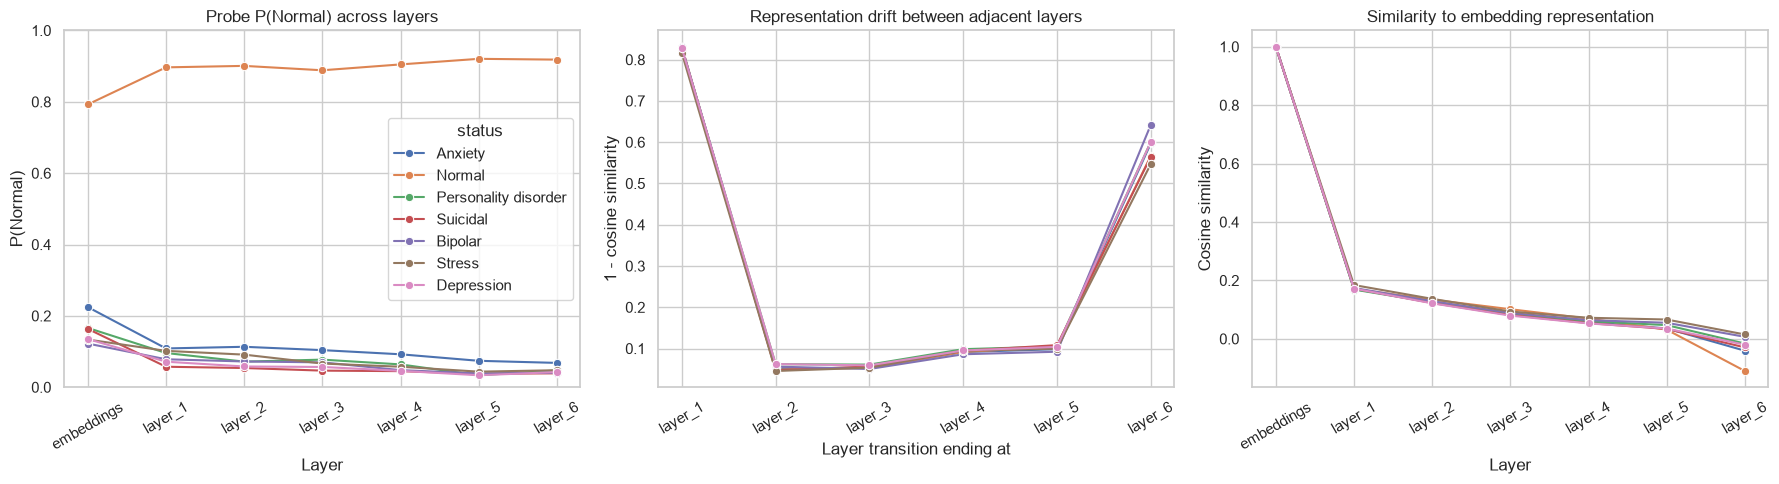

In [12]:
final_prefix_len = prefix_last_df.groupby("sample_id")["prefix_word_count"].max().rename("final_prefix_word_count")
final_layers = prefix_layer_df.merge(final_prefix_len, on="sample_id")
final_layers = final_layers[final_layers["prefix_word_count"] == final_layers["final_prefix_word_count"]].copy()

layer_summary = (
    final_layers.groupby(["status", "layer"], as_index=False)
    .agg(
        normal_probability=("normal_probability", "mean"),
        status_confidence=("status_confidence", "mean"),
        delta_from_previous_layer=("delta_from_previous_layer", "mean"),
        cosine_to_embeddings=("cosine_to_embeddings", "mean"),
    )
)
layer_summary["layer"] = pd.Categorical(layer_summary["layer"], categories=layer_names, ordered=True)
layer_summary = layer_summary.sort_values("layer")
layer_summary.to_csv(OUTPUT_DIR / "final_text_layer_summary_by_status.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=layer_summary, x="layer", y="normal_probability", hue="status", marker="o", ax=axes[0])
axes[0].set_title("Probe P(Normal) across layers")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("P(Normal)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylim(0, 1)

sns.lineplot(data=layer_summary[layer_summary["layer"] != "embeddings"], x="layer", y="delta_from_previous_layer", hue="status", marker="o", legend=False, ax=axes[1])
axes[1].set_title("Representation drift between adjacent layers")
axes[1].set_xlabel("Layer transition ending at")
axes[1].set_ylabel("1 - cosine similarity")
axes[1].tick_params(axis="x", rotation=30)

sns.lineplot(data=layer_summary, x="layer", y="cosine_to_embeddings", hue="status", marker="o", legend=False, ax=axes[2])
axes[2].set_title("Similarity to embedding representation")
axes[2].set_xlabel("Layer")
axes[2].set_ylabel("Cosine similarity")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "layer_to_layer_final_text_summary.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Prefix-by-layer heatmap for one row

This shows both requested axes at once: growing prefixes on the x-axis and DistilGPT2 layers on the y-axis.

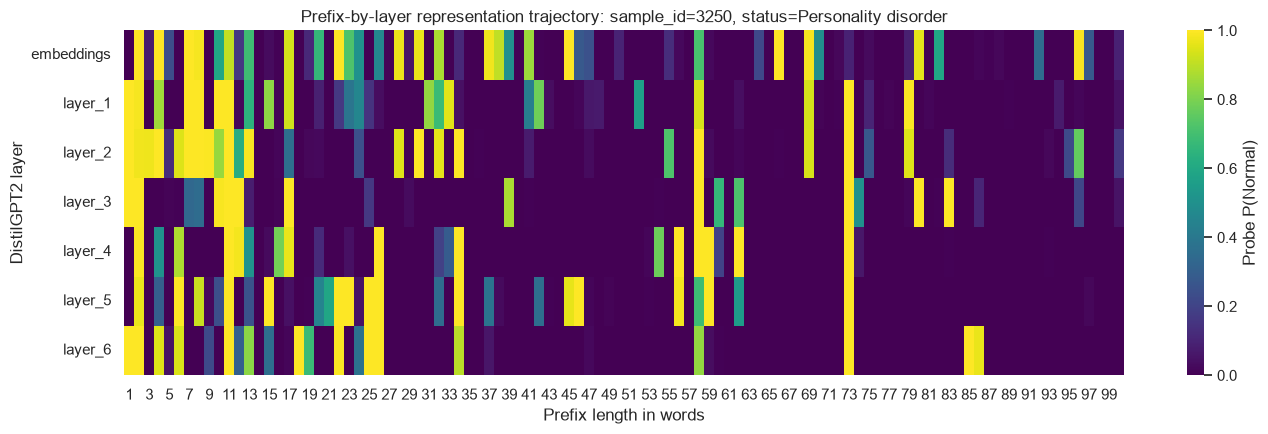

Statement:
Do you think someone with avpd have a chance in the music industry? So it’s been getting harder for me to keep a job. I’m still trying as hard as I can, I don’t wanna been seen as weak for not being able to keep a job. But it’s 2 things I do very well and that’s sing, and make beats . Do you think someone with avpd have a chance in the music industry? If I do the singing I know my anxiety would be crazy if I had to perform but I really have a passion for singing.


In [13]:
def plot_prefix_layer_heatmap(sample_id=None):
    if sample_id is None:
        sample_id = int(sample_df.sort_values("word_count", ascending=False)["sample_id"].iloc[0])
    row = sample_df.loc[sample_df["sample_id"] == sample_id].iloc[0]
    data = prefix_layer_df[prefix_layer_df["sample_id"] == sample_id].copy()
    data["layer"] = pd.Categorical(data["layer"], categories=layer_names, ordered=True)
    heat = data.pivot(index="layer", columns="prefix_word_count", values="normal_probability")

    fig, ax = plt.subplots(figsize=(14, 4.5))
    sns.heatmap(heat, cmap="viridis", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Probe P(Normal)"})
    ax.set_title(f"Prefix-by-layer representation trajectory: sample_id={sample_id}, status={row.status}")
    ax.set_xlabel("Prefix length in words")
    ax.set_ylabel("DistilGPT2 layer")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"prefix_layer_heatmap_sample_{sample_id}.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Statement:")
    print(row.statement)


plot_prefix_layer_heatmap()

## 11. Saved outputs

Outputs are written to `outputs/distilgpt2_word_by_word/`:

- `sample_500_rows.csv`: the exact sampled dataset rows
- `full_text_vectors_by_layer.npy`: full-text hidden states used for probes
- `probe_scores_by_layer.csv`: probe performance by layer
- `prefix_last_layer_trajectory.csv`: one row per prefix, last-layer metrics
- `prefix_layer_trajectory_long.csv`: one row per prefix per layer
- PNG plots for prefix trajectories, layer summaries, and heatmaps